# Ontologies creation using NAIVE approaches

This notebook explores an initial approach to the challenge of ontology creation using large language models (LLMs). We will follow a simple heuristic to generate results and evaluate output:

1. **Input:** We start by providing a domain name and 5-10 terms related to the domain from which we wish to generate an ontology. This will expand to include a domain and topic, a definition for both, and eventually additional initial terms.
   
2. Given the input, we will request a large language model (in this case, ChatGPT-4o) to return a number (to be defined) of related terms.
   
3. Following initial thesis on calculation of semantic distance, we will request the model to calculate distance between terms. We will then test by removing or not removing terms with the lowest semantic distance and by requesting step 2 multiple times (distill).
   
4. Given the output of step 3, we will cluster results using hierarchical clustering.
   
5. Clusters will be used to serialize as RDF with a predicate "as-is" and the terms internally with "is-related". At this stage, we will also test requesting an LLM to generate text using the given terms and the domain/topic to test the extraction of different relations.
   
6. We will plot the ontology.
   
7. Compare the output with similar results from dbpedia.org.


### Prompts used for semantic distance calculations

Based out of initial work we will use the following prompts which have be shown to return good results. For this initial experiment we will only use english prompts to isolate tasks. we don't wish to analyse model capacity for task execution on a multi language environment.

```txt
In this survey you’ll be asked to rate quantitatively, on a scale, the intensity of the semantic relatedness between pairs of affective words. Please, before starting, read carefully the instructions and the examples provided. 

The question we’re asking is: how much related are the two words? Vaguely related words should be scored with lower values, and strongly related words with higher values. Please note that opposite words frequently present high values of relatedness.

For example, the words ’modest’ and ’smart’ don’t seem very related. ’Conceal’ and ’mask’ seem very related. ’Confident’ is highly related with itself. ’Violent’ and ’pacific’, being opposite words, are frequently related, just like ’happiness’ and ’sadness’. 

Examples: 
* modest, smart: 1,
* conceal, mask: 4 
* confident, confident: 5 
* violent, pacific: 4 
* happiness, sadness: 5

Please rate from 0 to 4 the semantic relatedness of the following pairs of words, with 0 indicating words not related at all and 4 indicating very related words: 
apple, galaxy
fault, system
champion, winner 
town, city

```

In [20]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import json
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src.services import ChatGpt
from src.services import clustering
from src.services import Ontology

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## Experiment 1: 

**Description:** 

1. use a domain name and 10 terms related and request a term cloud. 
2. Request semantic distance between terms
3. No destil
4. Run hierarchy cluster
5. serialize into rdf

In [21]:
agent = ChatGpt()
agent.model = "gpt-4o-mini"

In [22]:
terms_list_str = agent.chat(
    instructions="You are a taxonomy and ontology expert. Provide concise and accurate responses based on the user's queries.",
    input="""
        Provide a list of 20 categories, terms or words closely related to domain or topic and using the provided terms as reference.
        
        - the domain or topic is: cinema
        - the provided terms are: 
            start trek, spoke, vulcan, klingon, enterprise
        
        Your output should be a json array with only the category names, without any additional text. 
        This categories should include the given terms and be closely related to the domain or topic.
        Do not encapsulate the output in code blocks.
        
        Example output:
        [
            "category1",
            "category2",
            ...            "category100"
        ]
        
    """
)

In [23]:
# Clean output. 
terms_list_json = json.loads(terms_list_str)
terms_list_df = pd.DataFrame(terms_list_json, columns=["category"])
print(terms_list_df.head(10))
print(terms_list_df.tail(10))

                 category
0               Star Trek
1                  Vulcan
2                 Klingon
3              Enterprise
4         Science Fiction
5             Space Opera
6       Television Series
7                Starship
8       Fictional Species
9  Intergalactic Politics
                 category
10        Cultural Impact
11         Film Franchise
12           Storytelling
13  Character Development
14             Set Design
15        Special Effects
16            Fan Culture
17          Merchandising
18          Narrative Arc
19     Cosmic Exploration


In [24]:
# Cartesian product with provided terms
terms_pair = pd.merge(terms_list_df, terms_list_df, how='cross')
terms_pair = terms_pair.drop(terms_pair[terms_pair['category_x'] == terms_pair['category_y']].index) # We don't need to analyse a term with itself

In [25]:
## Calculate similarity for each pair
similarity_df = agent.get_similarity(terms_pair)

In [26]:
similarity_df.groupby("similarity").size().reset_index(name='counts')

,similarity,counts
0,3,204
1,4,142
2,5,34


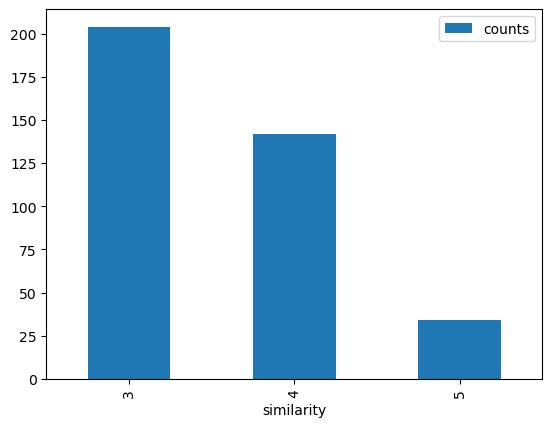

In [27]:
( 
    similarity_df
        .groupby("similarity")
        .size()
        .reset_index(name='counts')
        .plot(kind='bar', x='similarity', y='counts')
);

In [28]:
similarity_df['category_x'].unique()

array(['Star Trek', 'Vulcan', 'Klingon', 'Enterprise', 'Science Fiction',
       'Space Opera', 'Television Series', 'Starship',
       'Fictional Species', 'Intergalactic Politics', 'Cultural Impact',
       'Film Franchise', 'Storytelling', 'Character Development',
       'Set Design', 'Special Effects', 'Fan Culture', 'Merchandising',
       'Narrative Arc', 'Cosmic Exploration'], dtype=object)

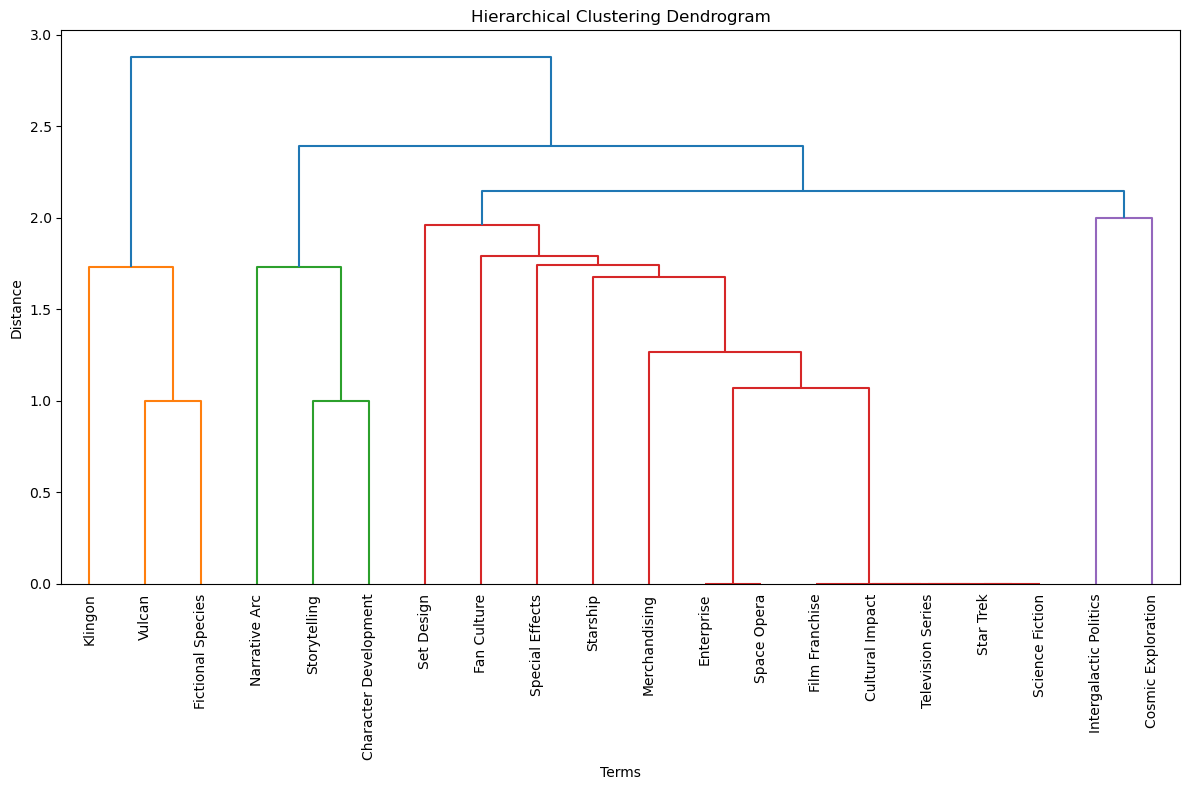

In [29]:
terms, distance_matrix, condensed_dist = clustering.create_distance_matrix(similarity_df, max_similarity = 5)

Z = linkage(condensed_dist, metric='euclidean', method="ward")

plt.figure(figsize=(12, 8))
dendrogram(Z, labels=terms, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Terms')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [30]:
# Extract clusters
distance_threshold = 1 # similar to a 3
clusters = fcluster(Z, t=distance_threshold, criterion='distance')
print(clusters)

[ 6  1  2  5  6  5  6  8  1 12  6  6  3  3 11  9 10  7  4 13]


In [31]:
cluster_df = pd.DataFrame({
    'term': terms,
    'cluster': clusters
})

cluster_df

,term,cluster
0,Star Trek,6
1,Vulcan,1
2,Klingon,2
3,Enterprise,5
4,Science Fiction,6
5,Space Opera,5
6,Television Series,6
7,Starship,8
8,Fictional Species,1
9,Intergalactic Politics,12


In [32]:
cluster_names = cluster_df.groupby('cluster')['term'].apply(agent.generate_cluster_name)
cluster_df['cluster_name'] = cluster_df['cluster'].map(cluster_names)
cluster_df

,term,cluster,cluster_name
0,Star Trek,6,Space Opera
1,Vulcan,1,Science Fiction Species
2,Klingon,2,Klingon Language
3,Enterprise,5,Sci-Fi Genres
4,Science Fiction,6,Space Opera
5,Space Opera,5,Sci-Fi Genres
6,Television Series,6,Space Opera
7,Starship,8,Spacecraft
8,Fictional Species,1,Science Fiction Species
9,Intergalactic Politics,12,Intergalactic Diplomacy


In [33]:
ontology = Ontology()
ontology.build_ontology(cluster_df)
ontology.serialize_ontology(format='turtle')

'@prefix ex: <http://example.org/ontology/> .\n@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .\n\nex:Cosmic_Exploration rdfs:label "Cosmic Exploration" ;\n    rdfs:subClassOf ex:Cosmos .\n\n'

In [ ]:
def visualize(g):
    stream = io.StringIO()
    rdf2dot(g, stream, opts = {display})
    dg = pydotplus.graph_from_dot_data(stream.getvalue())
    png = dg.create_png()
    display(Image(png))

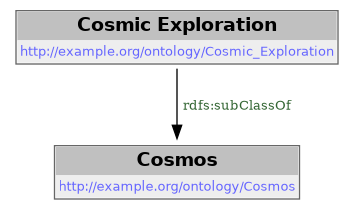

In [45]:
import io
import pydotplus

stream = io.StringIO()
rdf2dot(ontology.rdf, stream, opts = {display})
graph = pydotplus.graph_from_dot_data(stream.getvalue())
png_data = graph.create_png()
display(Image(png_data))

In [41]:
stream

In [35]:
ontology.visualize()


^
Expected {'GRAPH' | 'DIGRAPH'}  (at char 0), (line:1, col:1)


AttributeError: 'NoneType' object has no attribute 'create_png'

In [16]:
from rdflib import Graph, Namespace, RDF, RDFS, Literal, URIRef

# Create a new RDF graph
g = Graph()

# Define namespaces
base_ns = Namespace("http://example.org/ontology/")
related = Namespace("http://example.org/ontology/related/")

# Bind prefixes for cleaner output
g.bind("ex", base_ns)
g.bind("related", related)

# Add terms and relationships to the graph
for cluster_id in cluster_df['cluster'].unique():
    cluster_terms = cluster_df[cluster_df['cluster'] == cluster_id]
    cluster_name = cluster_terms.iloc[0]['cluster_name']
    
    # Create URI for the cluster
    cluster_uri = base_ns[cluster_name.replace(" ", "_")]
    
    # Add each term in the cluster
    for _, row in cluster_terms.iterrows():
        term = row['term']
        term_uri = base_ns[term.replace(" ", "_")]
        
        # Term is subclass of cluster
        g.add((term_uri, RDFS.subClassOf, cluster_uri))
        g.add((term_uri, RDFS.label, Literal(term)))
        
        # Add related relationships between terms in the same cluster
        for _, other_row in cluster_terms.iterrows():
            if row['term'] != other_row['term']:
                other_term_uri = base_ns[other_row['term'].replace(" ", "_")]
                g.add((term_uri, related['to'], other_term_uri))

# Serialize to different formats
print("=== Turtle Format ===")
print(g.serialize(format='turtle'))

# Save to file
# output_path = Path.cwd().parent / "output" / "ontology.ttl"
# output_path.parent.mkdir(exist_ok=True)
# g.serialize(destination=str(output_path), format='turtle')
# print(f"\nSaved to: {output_path}")

=== Turtle Format ===
@prefix ex: <http://example.org/ontology/> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix related: <http://example.org/ontology/related/> .

ex:alien_species rdfs:label "alien species" ;
    rdfs:subClassOf ex:Extraterrestrial .

ex:character_development rdfs:label "character development" ;
    rdfs:subClassOf ex:Character_Arc .

ex:cosmic_exploration rdfs:label "cosmic exploration" ;
    rdfs:subClassOf ex:Space_Exploration .

ex:film_direction rdfs:label "film direction" ;
    rdfs:subClassOf ex:Film_Directing .

ex:futurism rdfs:label "futurism" ;
    rdfs:subClassOf ex:Futurism .

ex:klingon rdfs:label "klingon" ;
    rdfs:subClassOf ex:Klingon_Culture .

ex:merchandising rdfs:label "merchandising" ;
    rdfs:subClassOf ex:Retail_Strategy .

ex:narrative_structure rdfs:label "narrative structure" ;
    rdfs:subClassOf ex:Storytelling .

ex:screenwriting rdfs:label "screenwriting" ;
    rdfs:subClassOf ex:Screenwriting .

ex:spoke rdfs:label 

In [17]:
# helper function for visualizing RDF graphs
def visualize(g):
    stream = io.StringIO()
    rdf2dot(g, stream, opts = {display})
    dg = pydotplus.graph_from_dot_data(stream.getvalue())
    png = dg.create_png()
    display(Image(png))

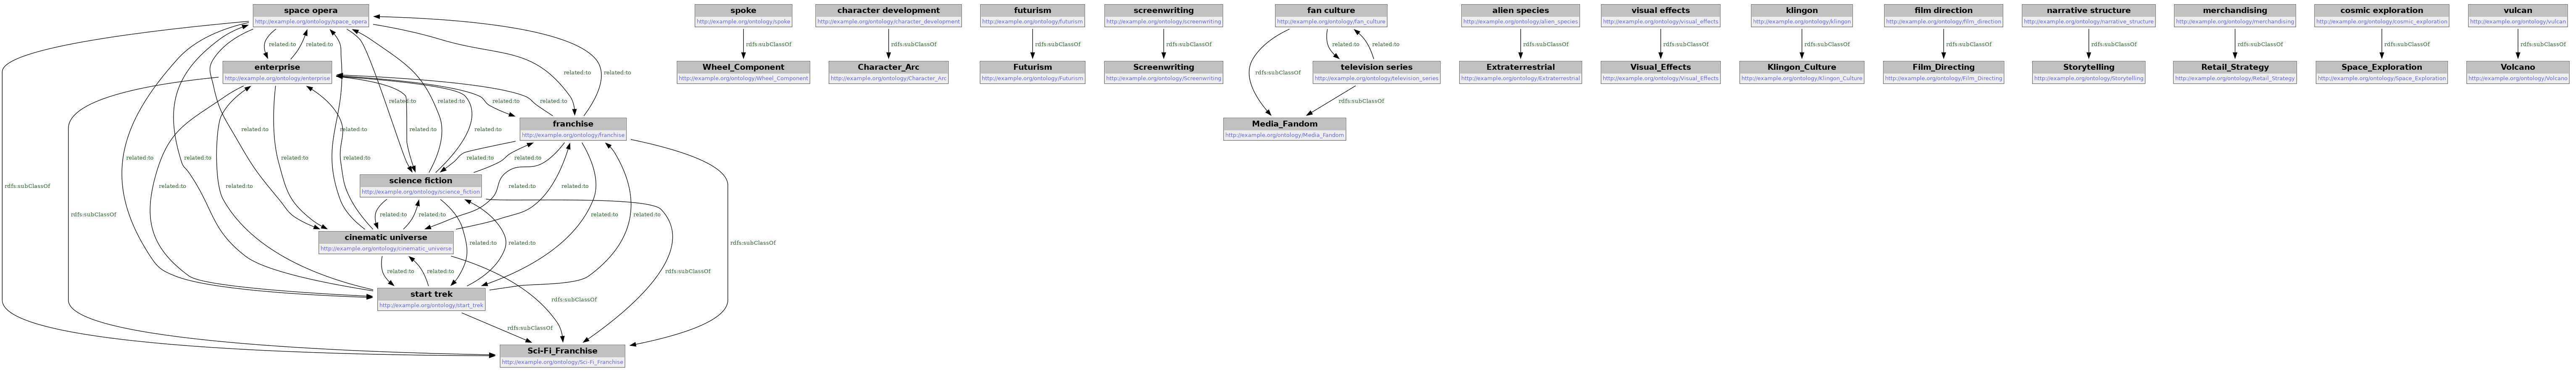

In [18]:
import io
import pydotplus
from IPython.display import display, Image
from rdflib.tools.rdf2dot import rdf2dot

visualize(g)